Import Req. Libraries
    TensorFlow/Keras for Deep Learning
    NumPy for numerical operations
    Matplotlib for visualization
    Seaborn for better plots

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Dataset - CIFAR-10
The CIFAR-10 dataset contains:
    60,000 color images
    10 image classes
    32x32 image size

dataset contains these classes:
    0. Airplane
    1. Automobile
    2. Bird
    3. Cat
    4. Deer
    5. Dog
    6. Frog
    7. Horse
    8. Ship
    9. Truck

In [3]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [6]:
print("Unique Labels in Dataset:")
print(np.unique(y_train))

Unique Labels in Dataset:
[0 1 2 3 4 5 6 7 8 9]


In [7]:
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat',
               'Deer', 'Dog', 'Frog', 'Horse',
               'Ship', 'Truck']

print("Class Labels:\n")

Class Labels:



In [8]:
for i, name in enumerate(class_names):
    print(i, ":", name)

print("\nImage Data Type:", x_train.dtype)

0 : Airplane
1 : Automobile
2 : Bird
3 : Cat
4 : Deer
5 : Dog
6 : Frog
7 : Horse
8 : Ship
9 : Truck

Image Data Type: uint8


In [9]:
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


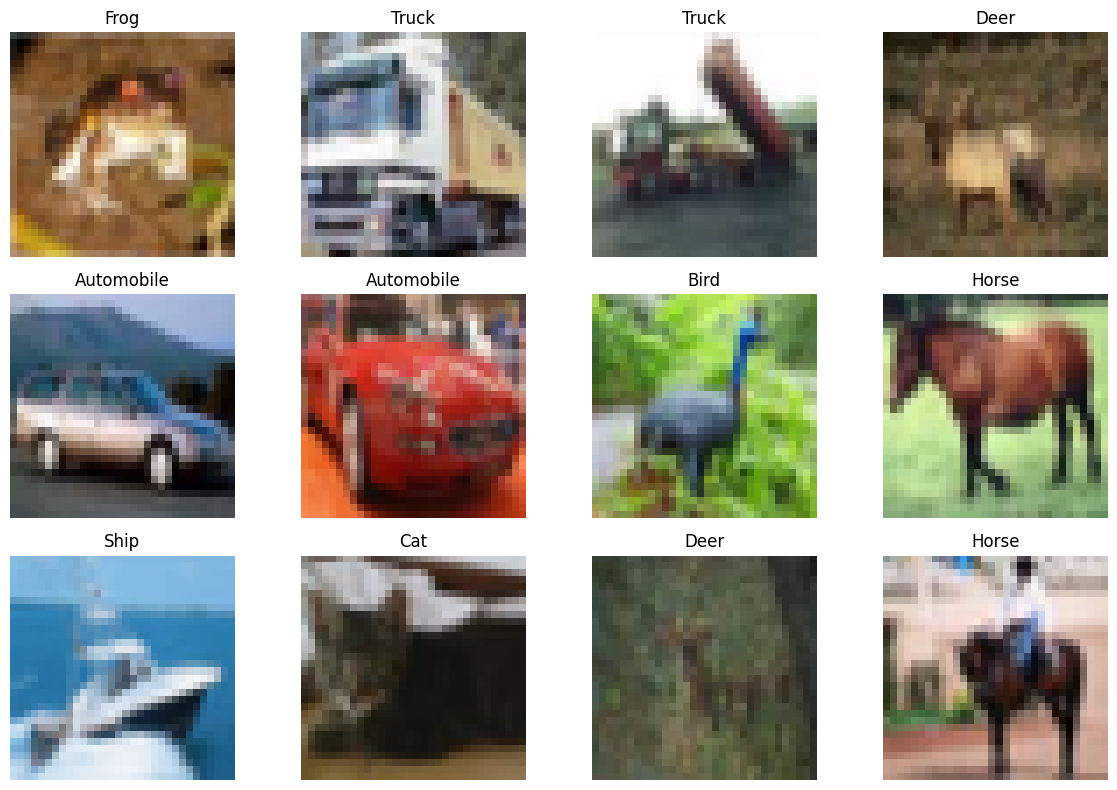

In [10]:
# Displaying sample images from dataset
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

Data Preprocessing -->  normalize pixel values from: 0–255 → 0–1

In [11]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [12]:
print("Training Label Shape:", y_train.shape)
print("Testing Label Shape:", y_test.shape)

# Displaying first 10 labels
print("\nFirst 10 Training Labels:\n")

print(y_train[:10])

Training Label Shape: (50000, 1)
Testing Label Shape: (10000, 1)

First 10 Training Labels:

[[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]


CNN Model:
Layers Used:
    Conv2D
    MaxPooling2D
    Conv2D
    MaxPooling2D
    Conv2D
    MaxPooling2D
    Flatten
    Dense
    Dropout
    Dense(Output)

CNN Flow: Image passes through:
    Image-> Feature Extraction-> Pooling-> Flatten-> Classification-> Prediction

The CNN model consists of:
    Convolution layers for feature extraction
    Max pooling layers for dimensionality reduction
    Flatten layer for converting feature maps into vectors
    Dense layers for classification
    Dropout layer to reduce overfitting

In [14]:
model = models.Sequential()

# First Convolution Block
model.add(layers.Conv2D(32, (3, 3),
                        activation='relu',
                        input_shape=(32, 32, 3)))

model.add(layers.MaxPooling2D((2, 2)))

# Second Convolution Block
model.add(layers.Conv2D(64, (3, 3),
                        activation='relu'))

model.add(layers.MaxPooling2D((2, 2)))

# Third Convolution Block
model.add(layers.Conv2D(64, (3, 3),
                        activation='relu'))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(64, activation='relu'))

# Dropout Layer
model.add(layers.Dropout(0.5))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

In [15]:
# Display model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile CNN Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Trainng the model
During training:
    The model learns image patterns
    Weights are updated using backpropagation
    Accuracy improves gradually over epochs

In [18]:
history = model.fit(x_train, y_train, epochs=25, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.2820 - loss: 1.9254 - val_accuracy: 0.5117 - val_loss: 1.3621
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4723 - loss: 1.4592 - val_accuracy: 0.5702 - val_loss: 1.2122
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5388 - loss: 1.2973 - val_accuracy: 0.5975 - val_loss: 1.1354
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5807 - loss: 1.1900 - val_accuracy: 0.6300 - val_loss: 1.0428
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6117 - loss: 1.1057 - val_accuracy: 0.6423 - val_loss: 1.0123
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6423 - loss: 1.0368 - val_accuracy: 0.6707 - val_loss: 0.9416
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6600 - loss: 0.9779 - val_accuracy: 0.6841 - val_loss: 0.9149
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6770 - loss: 0.9318 - val_a

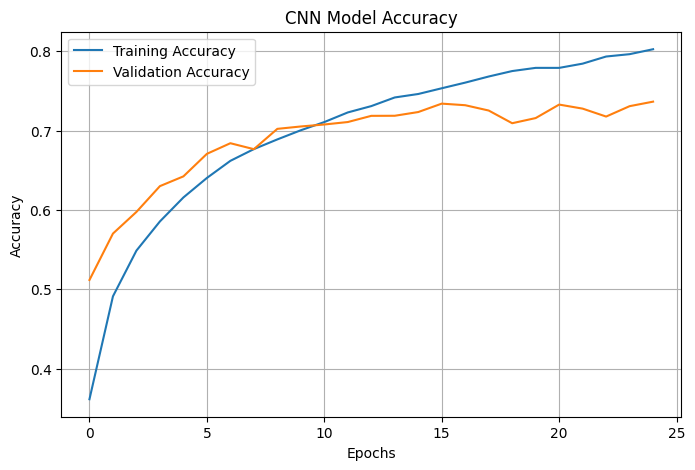

In [19]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

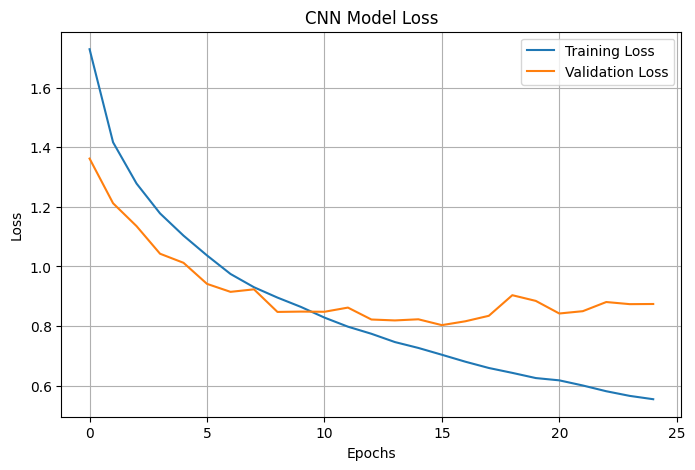

In [20]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Evaluation helps measure:
    Final model accuracy
    Prediction error on unseen data

In [21]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7393 - loss: 0.8692

Test Loss: 0.8740936517715454
Test Accuracy: 0.7365000247955322


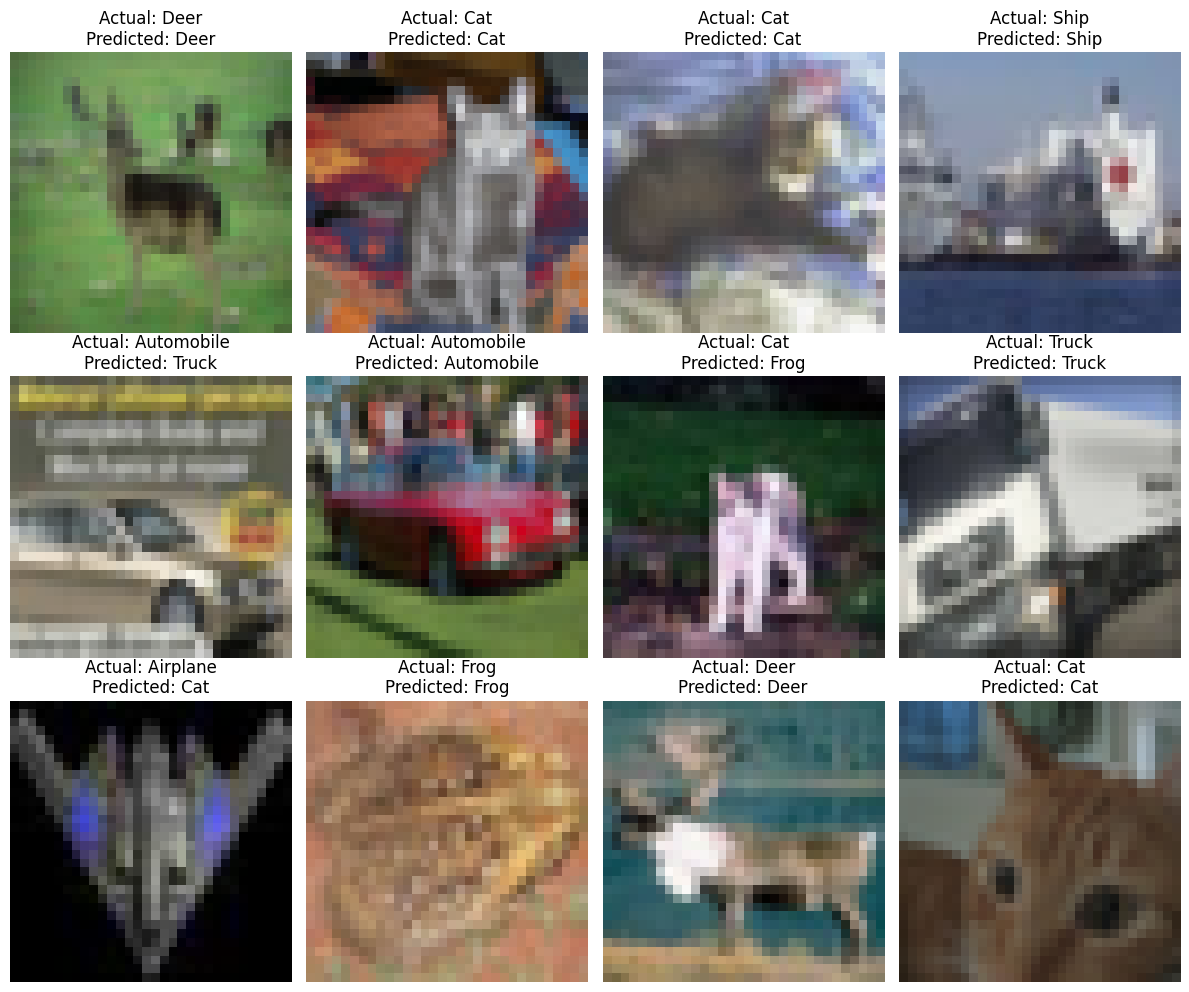

In [26]:
# Predict sample test images
plt.figure(figsize=(12, 10))

for i in range(12):
    # Select random image index
    idx = np.random.randint(0, len(x_test))
    # Predict image
    prediction = model.predict(x_test[idx].reshape(1, 32, 32, 3), verbose=0)
    predicted_class = np.argmax(prediction)
    actual_class = y_test[idx][0]
    # Display image
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])
    # Show prediction
    plt.title(f"Actual: {class_names[actual_class]}\nPredicted: {class_names[predicted_class]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [27]:
model.save("cnn_model.h5")